In [2]:
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using Plots
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities


include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")

merge_jld2_folder

In [3]:
folder = "data/N=(3, 3)_3x2"
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
U_values = e_metadata["meta_data"]["U_values"]
dim = [parse(Int, x) for x in split(e_metadata["meta_data"]["sites"], "x")]
shared_data = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=(3, 3)_shared.jld2"))
coefficient_data = []
interaction_data = []
loss = []
initial_loss = [] 
for i = 6:61#2:61
    dic = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=(3, 3)_u_$i.jld2"))
    push!(coefficient_data, dic["coefficients"][2])
    push!(interaction_data, U_values[i])
    push!(loss, dic["metrics"]["loss"][2])
    push!(initial_loss, dic["metrics"]["loss"][1])
end
coefficient_data = reduce(hcat, coefficient_data);

┌ Warning: type Main.#f_adjoint#154{Bool,Vector{ComplexF64},Vector{ComplexF64},Int64,Nothing,Nothing,Vector{Any},Vector{Int64},Vector{Float64},Vector{Int64},Vector{Int64}} does not exist in workspace; reconstructing
└ @ JLD2 /Users/jonathonkambulow/.julia/packages/JLD2/hbsZG/src/data/reconstructing_datatypes.jl:588
┌ Warning: some parameters could not be resolved for type OptimizationFunction{true,AutoZygote,JLD2.ReconstructedMutable{Symbol("#f_adjoint#154{Bool,Vector{ComplexF64},Vector{ComplexF64},Int64,Nothing,Nothing,Vector{Any},Vector{Int64},Vector{Float64},Vector{Int64},Vector{Int64}}"), (:use_symmetry, :antihermitian, :state1, :state2, :dim, :parity, :parameter_mapping, :ops, :param_index_map, :signs, :cols, :rows), Tuple{Any, Bool, Any, Any, Int64, Nothing, Nothing, Vararg{Any, 5}}},Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME),Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Noth

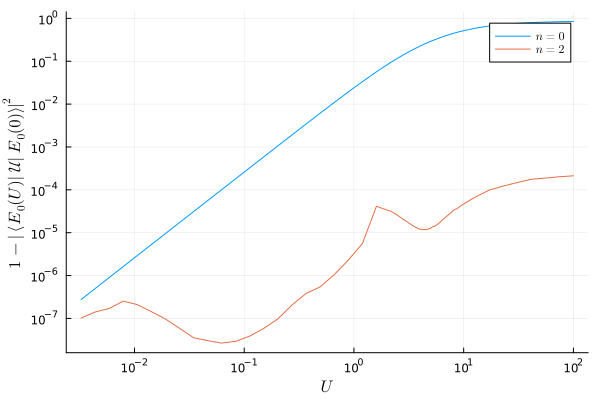

In [69]:
plot(yscale=:log10, xscale=:log10, ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", yticks=10.0 .^(-10:0), xticks=10.0 .^(-3:3))
plot!(interaction_data, initial_loss, label=L"n=0")
plot!(interaction_data, loss, label=L"n=2")

In [8]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
x = []
y = []
z = []
z1 = []
z2 = []
target_spin = 3 .-[1,2,1,2]
selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
    # k1 + k2 -> k1' + k2'
    if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
        continue
    end
    # display(shared_data["coefficient_labels"][2][i])
    s = sum(abs2, (collect((shared_data["coefficient_labels"][2][i][1][1] +  shared_data["coefficient_labels"][2][i][2][1]).coordinates) .- 2)) # (k1 + k2)^2
    t = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][1+order][1]).coordinates) # (k1 - k1')^2
    u = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][2+order][1]).coordinates) # (k1 - k2')^2
    # println("($s, $t, $u): $(u_data["coefficient_values"][2][i])")

    # push!(x, (u -t)+(rand()*2-1)*0.2)
    push!(x, s)
    push!(y, t)
    push!(z, u)
    # push!(y, s+(rand()*2-1)*0.2)
    selected_coefficient_index[i] = true

end


# scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")

high_range_mask = abs.(coefficient_data[:, 50]) .> 0.2
mid_range_mask = 0.05 .< abs.(coefficient_data[:, 50]) .< 0.2
low_range_mask = abs.(coefficient_data[:, 50]) .< 0.05
# histogram(abs.(coefficient_data[selected_coefficient_index, 50]), bins=30)

for i in eachindex(selected_coefficient_index)
    if !selected_coefficient_index[i] || !high_range_mask[i] 
        continue
    end
    display(shared_data["coefficient_labels"][2][i])
end

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(3, 1), 1, :create)
 (Coordinate(1, 2), 2, :annihilate)
 (Coordinate(3, 2), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(2, 1), 2, :create)
 (Coordinate(3, 1), 1, :create)
 (Coordinate(2, 2), 2, :annihilate)
 (Coordinate(3, 2), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(2, 1), 1, :create)
 (Coordinate(1, 2), 2, :annihilate)
 (Coordinate(2, 2), 1, :annihilate)

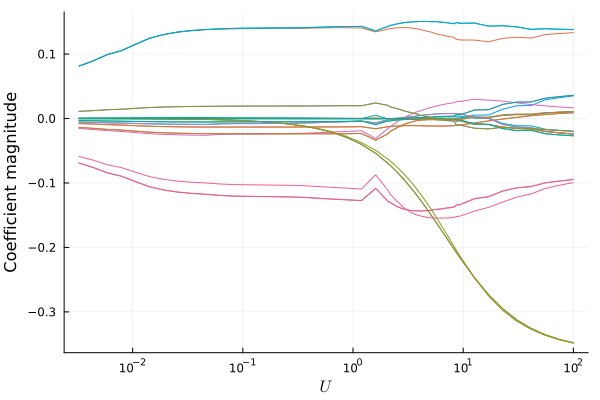

In [6]:
p = plot(interaction_data , coefficient_data[selected_coefficient_index, :]', legend=nothing, xlabel=L"U", ylabel="Coefficient magnitude", xscale=:log10)
savefig(p, "coefficient_magnitude.png")
savefig(p, "coefficient_magnitude.pdf")
display(p)

In [177]:
abs.(coefficient_data[selected_coefficient_index, :]) .> 0.05

27×56 BitMatrix:
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  1  1  1  1  1
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  1  1  1  1  1  1  1  1  1  1  1     1  1  1  1  1  1  1  1  1  1  1  1
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 ⋮              ⋮              ⋮        ⋱     ⋮              ⋮              ⋮
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0

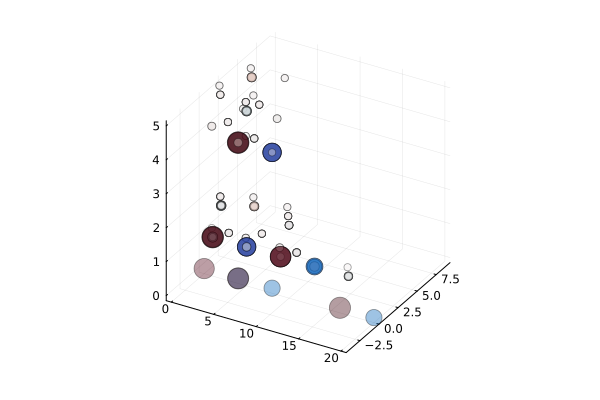

In [98]:
sizes = 4 .+ 8 .* abs.(val) ./ maximum(abs, val)

scatter(x, y, z,
    marker_z = val,
    ms = sizes,
    color = :balance,
    clim = clim,
    alpha = 0.4,
    legend = false,
    aspect_ratio = :equal)